Dataset shape: (65535, 19)

Q1 - KEY DEMOGRAPHIC PATTERNS

Gender counts:
SEX_CD
M    52979
F    12106
U      450
Name: count, dtype: int64


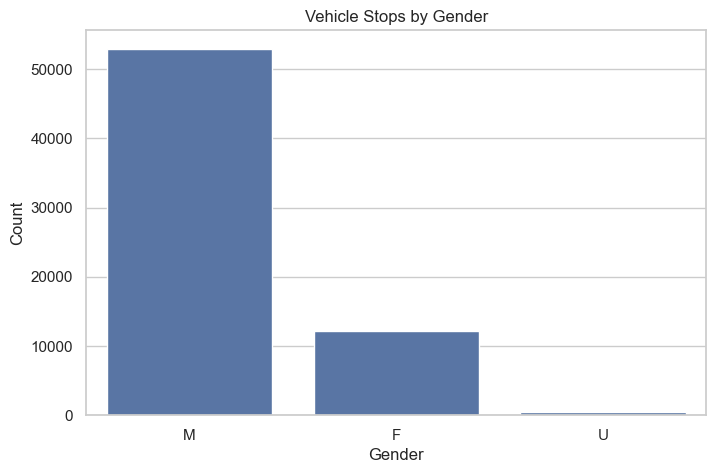


Age summary:
count    61950.000000
mean        38.474350
std         13.678601
min         16.000000
25%         27.000000
50%         36.000000
75%         48.000000
max        101.000000
Name: RPTED_AGE, dtype: float64


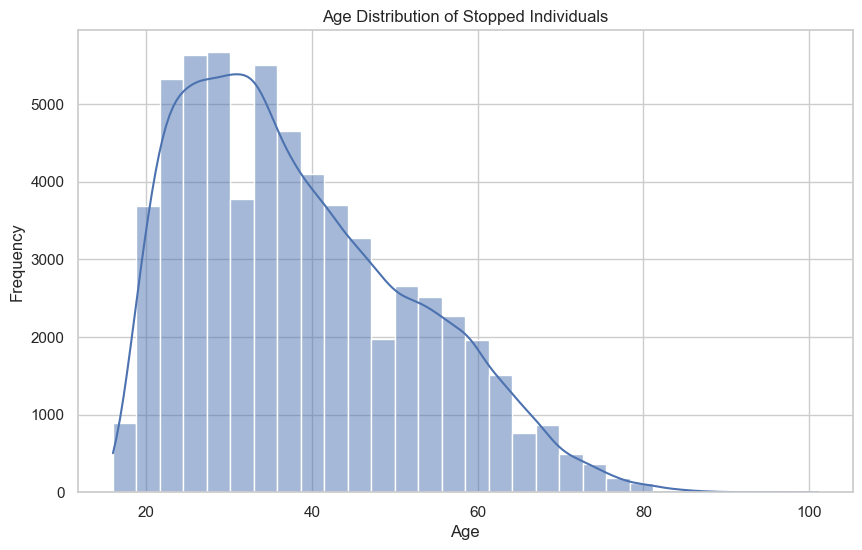


Race counts:
RACE_DESC
BLACK                             19090
HISPANIC                          18284
WHITE                             14090
ASIAN / PACIFIC ISLANDER           7742
UNKNOWN                            5304
AMERICAN INDIAN/ALASKAN NATIVE      771
OTHER                               254
Name: count, dtype: int64


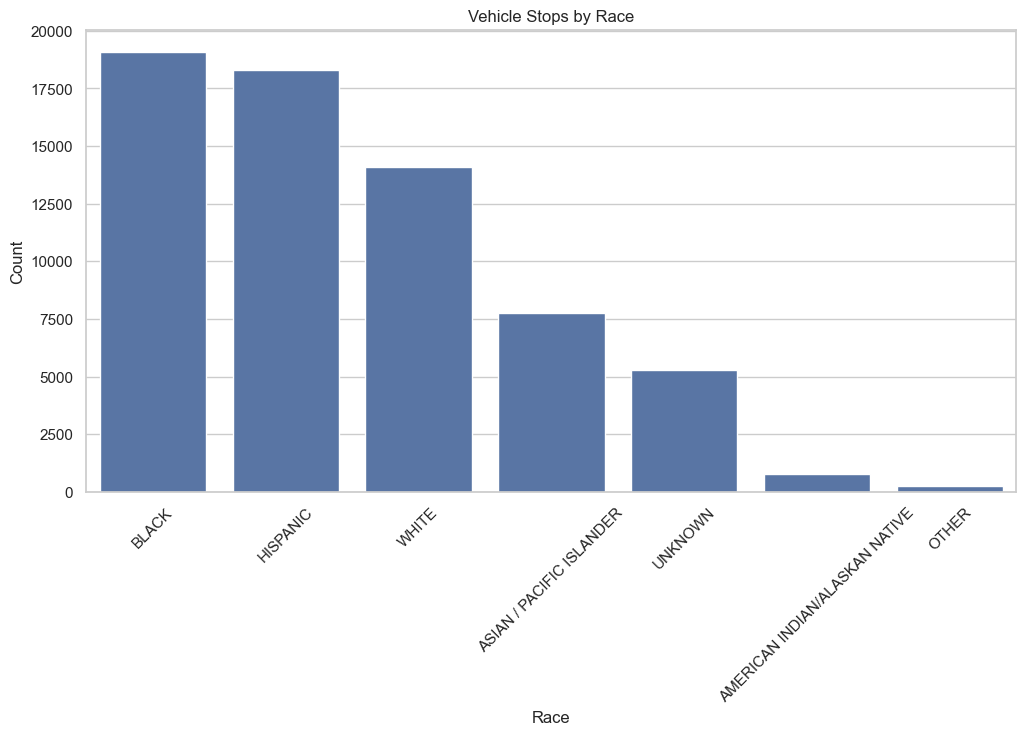


Chi-Square Test: Race vs Arrest
Chi2 Statistic: 594.3652568267142
p-value: 3.829692714879596e-125
Degrees of Freedom: 6

Q2 - AGE DISTRIBUTION BY RACE AND GENDER


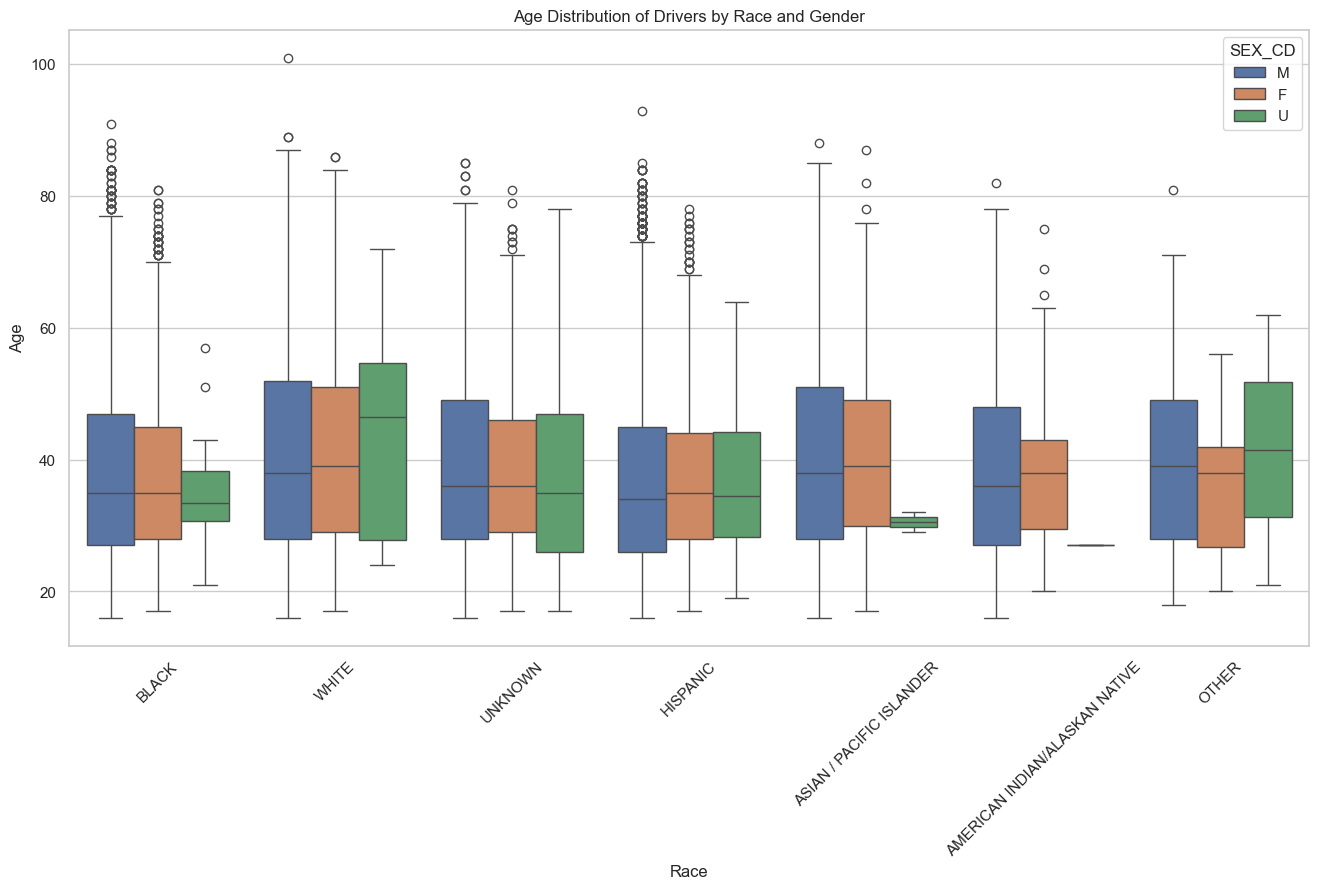


Q3 - POLICE ACTIONS BY LOCATION


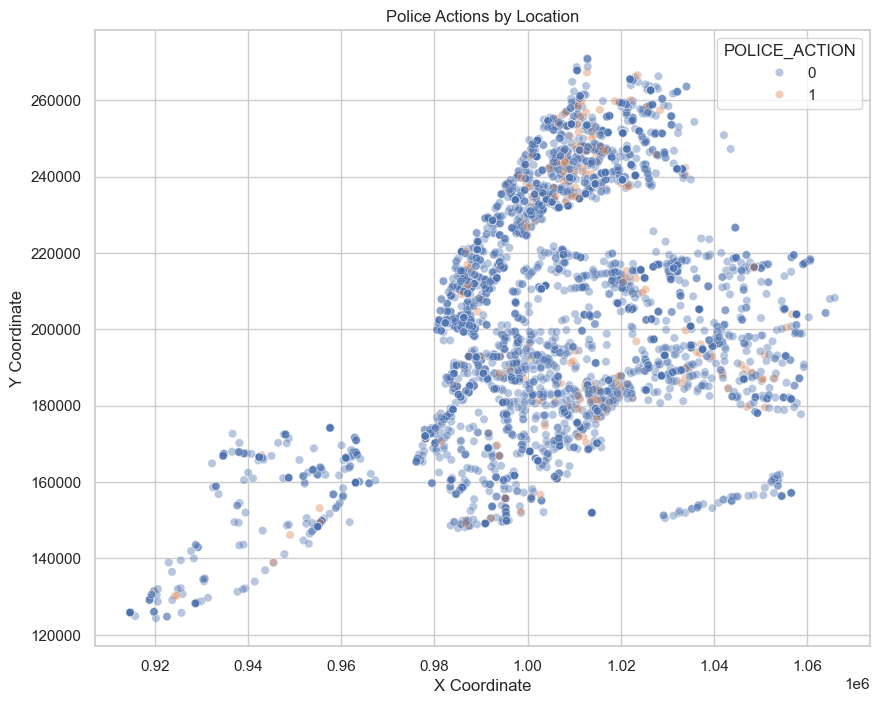

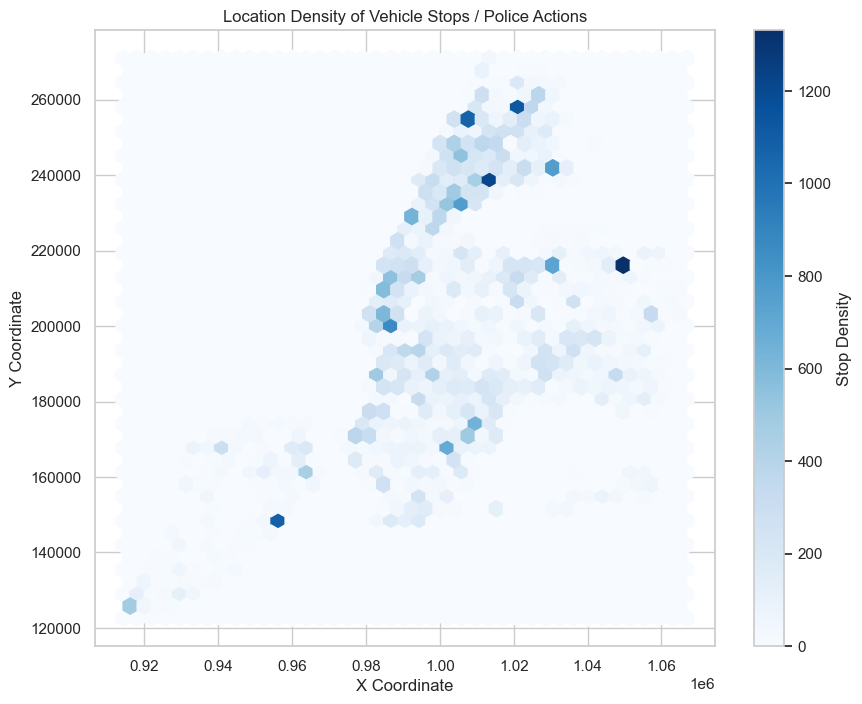


Q4 - FACTORS INFLUENCING VEHICLE SEARCH

Target distribution:
VEH_SEARCHED_FLG
0    63997
1     1538
Name: count, dtype: int64


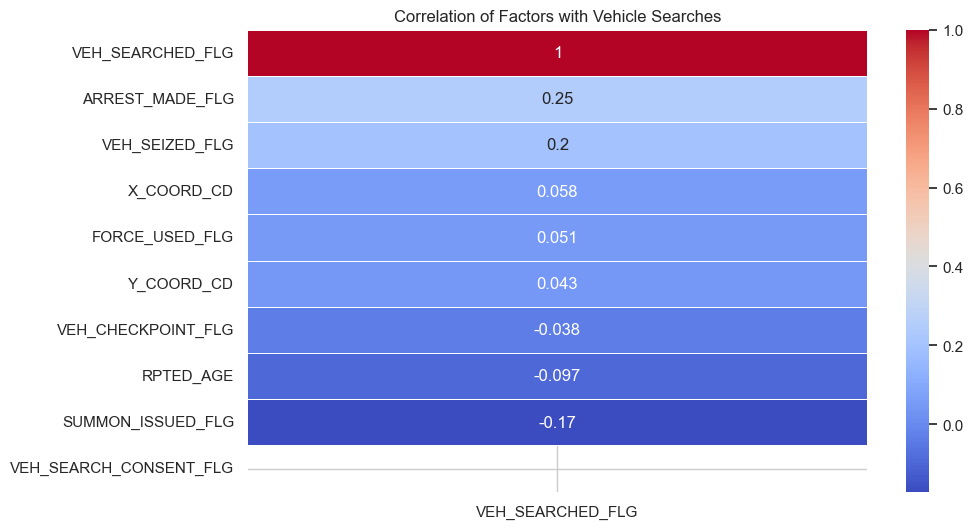


Accuracy: 0.7643
AUC Score: 0.8613

Confusion Matrix:
 [[9757 3042]
 [  47  261]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.76      0.86     12799
           1       0.08      0.85      0.14       308

    accuracy                           0.76     13107
   macro avg       0.54      0.80      0.50     13107
weighted avg       0.97      0.76      0.85     13107


Logistic Regression Coefficients:
              Feature  Coefficient
1      FORCE_USED_FLG     0.285570
5          Y_COORD_CD     0.000010
4          X_COORD_CD     0.000001
3           RPTED_AGE    -0.064267
0  VEH_CHECKPOINT_FLG    -2.466475
2   SUMMON_ISSUED_FLG    -2.867915

Q5 - ARREST PREDICTION USING RANDOM FOREST

Arrest target distribution:
ARREST_MADE_FLG
0    63817
1     1718
Name: count, dtype: int64

Before SMOTE:
ARREST_MADE_FLG
0    51054
1     1374
Name: count, dtype: int64

After SMOTE:
ARREST_MADE_FLG
0    51054
1    51054
Name: count, dtyp

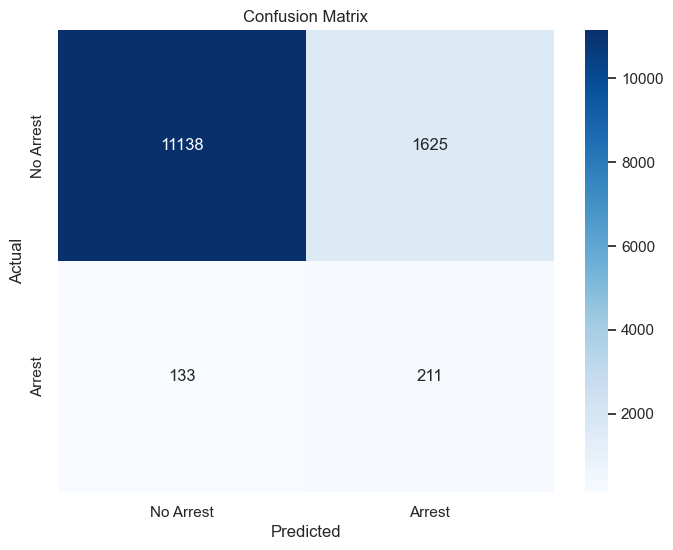

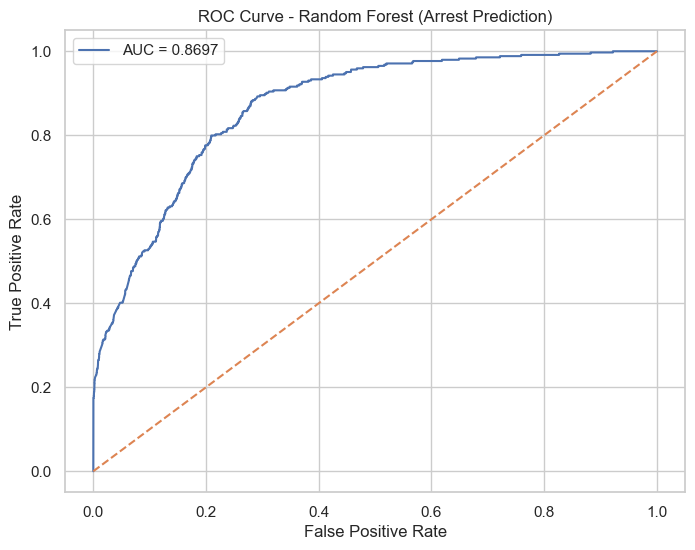


Feature Importances:
                  Feature  Importance
5       SUMMON_ISSUED_FLG    0.448641
0        VEH_SEARCHED_FLG    0.190330
1          VEH_SEIZED_FLG    0.129770
6               RPTED_AGE    0.092188
2  VEH_SEARCH_CONSENT_FLG    0.054948
3      VEH_CHECKPOINT_FLG    0.043465
8              Y_COORD_CD    0.022495
7              X_COORD_CD    0.014707
4          FORCE_USED_FLG    0.003456


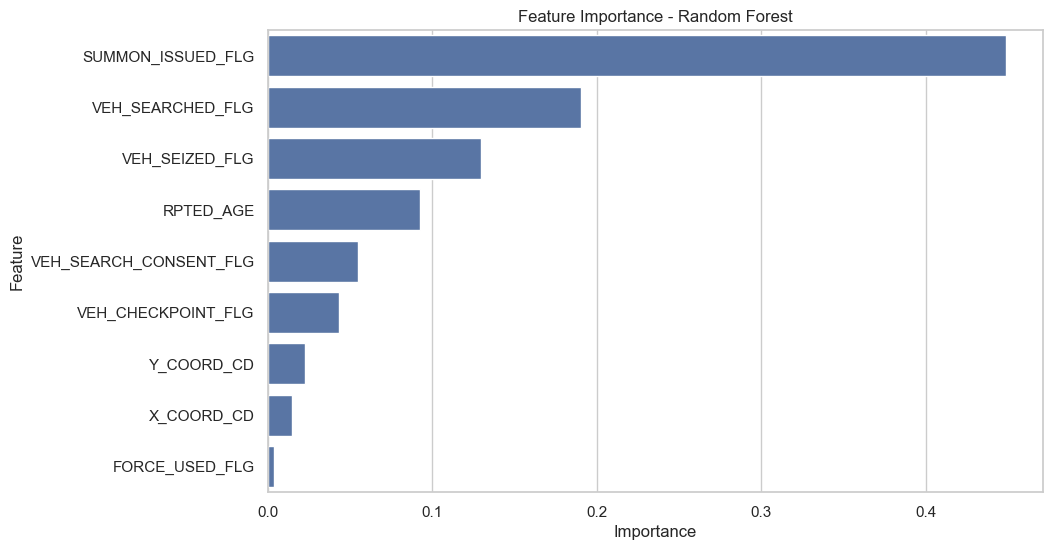


Analysis complete.


In [3]:
# =========================================================
# NYPD Vehicle Stop Analysis - Optimized Full Code
# =========================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
from imblearn.over_sampling import SMOTE

sns.set(style="whitegrid")

# -----------------------------
# 0. Load Data
# -----------------------------
file_path = os.path.join("..", "data", "NYPD_Vehicle_Stop_Reports.xlsx")
df = pd.read_excel(file_path)

# -----------------------------
# 1. Preprocessing
# -----------------------------
binary_cols = [
    'VEH_SEIZED_FLG',
    'VEH_SEARCHED_FLG',
    'VEH_SEARCH_CONSENT_FLG',
    'VEH_CHECKPOINT_FLG',
    'FORCE_USED_FLG',
    'ARREST_MADE_FLG',
    'SUMMON_ISSUED_FLG'
]

for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({'Y': 1, 'N': 0, True: 1, False: 0})

if 'RPTED_AGE' in df.columns:
    df['RPTED_AGE'] = pd.to_numeric(df['RPTED_AGE'], errors='coerce')

if 'SEX_CD' in df.columns:
    df['SEX_CD'] = df['SEX_CD'].astype(str).str.strip().str.upper()

if 'RACE_DESC' in df.columns:
    df['RACE_DESC'] = df['RACE_DESC'].astype(str).str.strip().str.upper()

print("Dataset shape:", df.shape)

# =========================================================
# Q1 - Key Demographic Patterns
# =========================================================
print("\n" + "="*70)
print("Q1 - KEY DEMOGRAPHIC PATTERNS")
print("="*70)

# Gender distribution
gender_counts = df['SEX_CD'].value_counts(dropna=False)
print("\nGender counts:")
print(gender_counts)

plt.figure(figsize=(8, 5))
sns.barplot(x=gender_counts.index, y=gender_counts.values)
plt.title("Vehicle Stops by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

# Age distribution
print("\nAge summary:")
print(df['RPTED_AGE'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(df['RPTED_AGE'].dropna(), bins=30, kde=True)
plt.title("Age Distribution of Stopped Individuals")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Race distribution
race_counts = df['RACE_DESC'].value_counts(dropna=False)
print("\nRace counts:")
print(race_counts)

plt.figure(figsize=(12, 6))
sns.barplot(x=race_counts.index, y=race_counts.values)
plt.title("Vehicle Stops by Race")
plt.xlabel("Race")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Chi-square test
chi_df = df[['RACE_DESC', 'ARREST_MADE_FLG']].dropna()
contingency_table = pd.crosstab(chi_df['RACE_DESC'], chi_df['ARREST_MADE_FLG'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("\nChi-Square Test: Race vs Arrest")
print("Chi2 Statistic:", chi2)
print("p-value:", p)
print("Degrees of Freedom:", dof)

# =========================================================
# Q2 - Age Distribution by Race and Gender
# =========================================================
print("\n" + "="*70)
print("Q2 - AGE DISTRIBUTION BY RACE AND GENDER")
print("="*70)

q2_df = df[['RACE_DESC', 'SEX_CD', 'RPTED_AGE']].dropna()

plt.figure(figsize=(16, 8))
sns.boxplot(data=q2_df, x='RACE_DESC', y='RPTED_AGE', hue='SEX_CD')
plt.title("Age Distribution of Drivers by Race and Gender")
plt.xlabel("Race")
plt.ylabel("Age")
plt.xticks(rotation=45)
plt.legend(title='SEX_CD')
plt.show()

# =========================================================
# Q3 - Police Actions by Location
# =========================================================
print("\n" + "="*70)
print("Q3 - POLICE ACTIONS BY LOCATION")
print("="*70)

q3_df = df[['X_COORD_CD', 'Y_COORD_CD', 'VEH_SEARCHED_FLG', 'ARREST_MADE_FLG']].dropna(
    subset=['X_COORD_CD', 'Y_COORD_CD']
).copy()

q3_df['POLICE_ACTION'] = q3_df[['VEH_SEARCHED_FLG', 'ARREST_MADE_FLG']].fillna(0).max(axis=1)

# Smaller sample for speed
sample_q3 = q3_df.sample(min(5000, len(q3_df)), random_state=42)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=sample_q3,
    x='X_COORD_CD',
    y='Y_COORD_CD',
    hue='POLICE_ACTION',
    alpha=0.4
)
plt.title("Police Actions by Location")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.show()

plt.figure(figsize=(10, 8))
plt.hexbin(q3_df['X_COORD_CD'], q3_df['Y_COORD_CD'], gridsize=40, cmap='Blues')
plt.colorbar(label='Stop Density')
plt.title("Location Density of Vehicle Stops / Police Actions")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.show()

# =========================================================
# Q4 - Factors Influencing Vehicle Search
# =========================================================
print("\n" + "="*70)
print("Q4 - FACTORS INFLUENCING VEHICLE SEARCH")
print("="*70)

q4_cols = [
    'VEH_SEARCHED_FLG',
    'VEH_SEIZED_FLG',
    'VEH_SEARCH_CONSENT_FLG',
    'VEH_CHECKPOINT_FLG',
    'FORCE_USED_FLG',
    'ARREST_MADE_FLG',
    'SUMMON_ISSUED_FLG',
    'RPTED_AGE',
    'X_COORD_CD',
    'Y_COORD_CD'
]

df_q4 = df[q4_cols].dropna(subset=['VEH_SEARCHED_FLG']).copy()

print("\nTarget distribution:")
print(df_q4['VEH_SEARCHED_FLG'].value_counts(dropna=False))

corr_matrix = df_q4.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix[['VEH_SEARCHED_FLG']].sort_values(by='VEH_SEARCHED_FLG', ascending=False),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)
plt.title("Correlation of Factors with Vehicle Searches")
plt.show()

feature_cols_q4 = [
    'VEH_CHECKPOINT_FLG',
    'FORCE_USED_FLG',
    'SUMMON_ISSUED_FLG',
    'RPTED_AGE',
    'X_COORD_CD',
    'Y_COORD_CD'
]

X_q4 = df_q4[feature_cols_q4]
y_q4 = df_q4['VEH_SEARCHED_FLG']

imputer_q4 = SimpleImputer(strategy='median')
X_q4_imputed = pd.DataFrame(imputer_q4.fit_transform(X_q4), columns=X_q4.columns)

X_train_q4, X_test_q4, y_train_q4, y_test_q4 = train_test_split(
    X_q4_imputed, y_q4, test_size=0.2, random_state=42, stratify=y_q4
)

log_reg = LogisticRegression(max_iter=500, class_weight='balanced')
log_reg.fit(X_train_q4, y_train_q4)

y_pred_q4 = log_reg.predict(X_test_q4)
y_prob_q4 = log_reg.predict_proba(X_test_q4)[:, 1]

acc_q4 = accuracy_score(y_test_q4, y_pred_q4)
auc_q4 = roc_auc_score(y_test_q4, y_prob_q4)

print(f"\nAccuracy: {acc_q4:.4f}")
print(f"AUC Score: {auc_q4:.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test_q4, y_pred_q4))
print("\nClassification Report:\n", classification_report(y_test_q4, y_pred_q4))

coef_df_q4 = pd.DataFrame({
    'Feature': X_q4.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("\nLogistic Regression Coefficients:")
print(coef_df_q4)

# =========================================================
# Q5 - Arrest Prediction Using Random Forest
# =========================================================
print("\n" + "="*70)
print("Q5 - ARREST PREDICTION USING RANDOM FOREST")
print("="*70)

q5_cols = [
    'ARREST_MADE_FLG',
    'VEH_SEARCHED_FLG',
    'VEH_SEIZED_FLG',
    'VEH_SEARCH_CONSENT_FLG',
    'VEH_CHECKPOINT_FLG',
    'FORCE_USED_FLG',
    'SUMMON_ISSUED_FLG',
    'RPTED_AGE',
    'X_COORD_CD',
    'Y_COORD_CD'
]

df_q5 = df[q5_cols].dropna(subset=['ARREST_MADE_FLG']).copy()

print("\nArrest target distribution:")
print(df_q5['ARREST_MADE_FLG'].value_counts(dropna=False))

X_q5 = df_q5.drop(columns=['ARREST_MADE_FLG'])
y_q5 = df_q5['ARREST_MADE_FLG']

imputer_q5 = SimpleImputer(strategy='median')
X_q5_imputed = pd.DataFrame(imputer_q5.fit_transform(X_q5), columns=X_q5.columns)

X_train_q5, X_test_q5, y_train_q5, y_test_q5 = train_test_split(
    X_q5_imputed, y_q5, test_size=0.2, random_state=42, stratify=y_q5
)

print("\nBefore SMOTE:")
print(y_train_q5.value_counts())

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_q5, y_train_q5)

print("\nAfter SMOTE:")
print(pd.Series(y_train_sm).value_counts())

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_sm, y_train_sm)

y_pred_q5 = rf_model.predict(X_test_q5)
y_prob_q5 = rf_model.predict_proba(X_test_q5)[:, 1]

acc_q5 = accuracy_score(y_test_q5, y_pred_q5)
auc_q5 = roc_auc_score(y_test_q5, y_prob_q5)

print(f"\nAccuracy: {acc_q5:.4f}")
print(f"AUC Score: {auc_q5:.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test_q5, y_pred_q5))
print("\nClassification Report:\n", classification_report(y_test_q5, y_pred_q5))

cm_q5 = confusion_matrix(y_test_q5, y_pred_q5)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_q5,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Arrest', 'Arrest'],
    yticklabels=['No Arrest', 'Arrest']
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Keep ONLY this ROC curve
fpr_q5, tpr_q5, _ = roc_curve(y_test_q5, y_prob_q5)

plt.figure(figsize=(8, 6))
plt.plot(fpr_q5, tpr_q5, label=f"AUC = {auc_q5:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest (Arrest Prediction)")
plt.legend()
plt.show()

feature_importance = pd.DataFrame({
    'Feature': X_q5.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importances:")
print(feature_importance)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature')
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

print("\nAnalysis complete.")